stroke: 0.11299999999999999


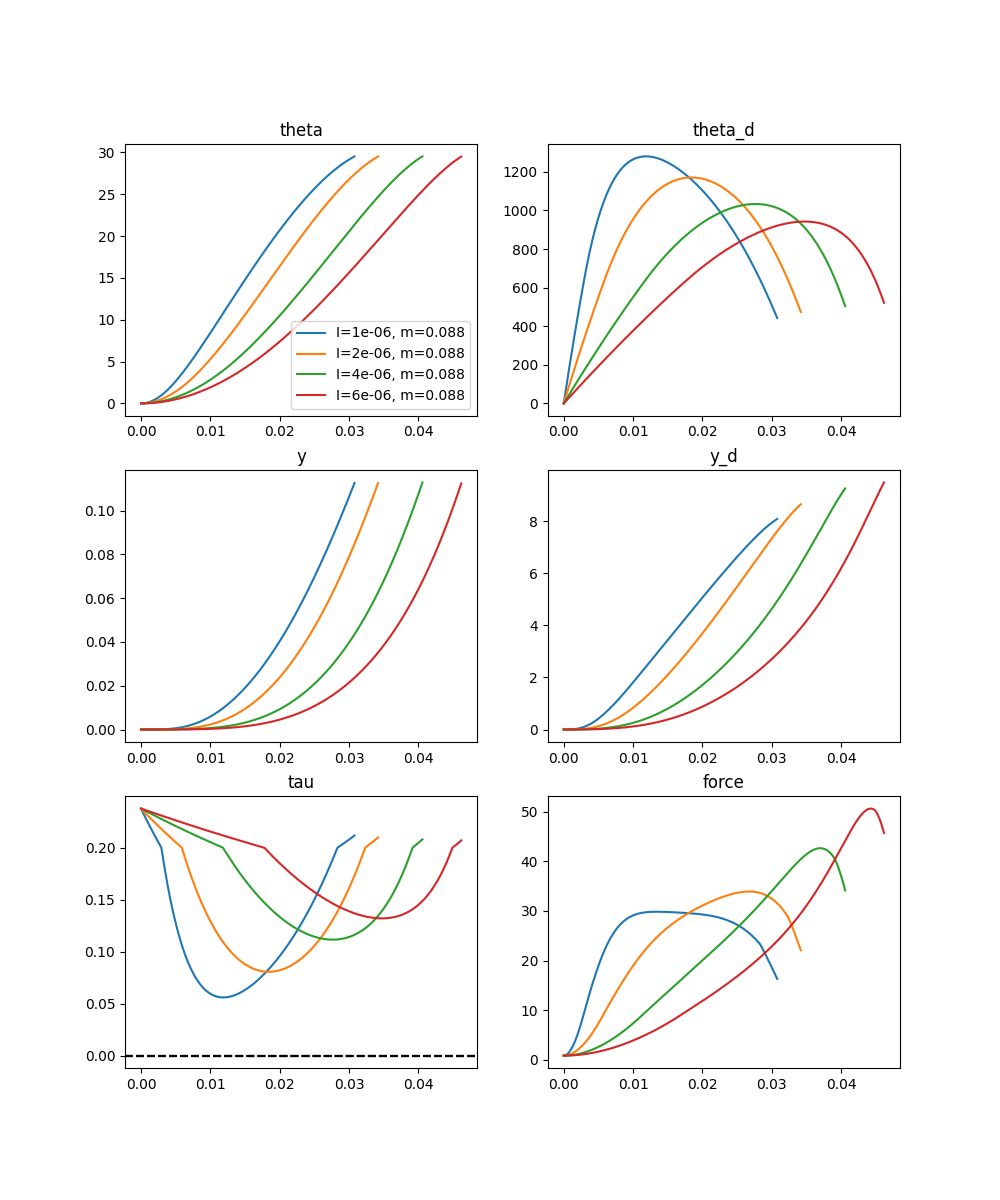

In [68]:
import numpy as np
from scipy.integrate import solve_ivp
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib widget
plt.close('all')

L = 34*0.0045 #32 spacers, 4.5mm spacing
r = 0.005
stroke = L - 32*0.00125 #each spacer is 1.25mm
voltage = 7
motor_KV = 2200 #rpm
w_max = voltage * motor_KV / 60 * (2 * np.pi)
mass = 0.0883 #just the body
# mass = 0.040
# I = 2.2e-5 #from Ingo's winter 2026 report, fitted from data
I = 7e-6 #f
print(f"stroke: {stroke}")

params = {
    'm': mass,
    'I': I,
    'stroke': stroke,
    'g': 9.81,
    'tau_max': 0.22,
    'w_max': w_max,
}

def get_y_tsa(theta):
    val = L**2 - (r*theta)**2
    if val < 1e-12:
        val = 1e-12
    y = L - np.sqrt(val)
    dy_dtheta = (r**2 * theta) / np.sqrt(val)
    d2y_dtheta2 = (r**2 * L**2) / (val)**(3/2)
    return y, dy_dtheta, d2y_dtheta2

def get_tau(theta, theta_dot, t):
    #linear fit at 7V
    rpm = theta_dot * 60 / (2 * np.pi)
    y1 = ((0.2 - 0.2375) / (6110 - 0)) * (rpm - 0) + 0.2375
    y2 = (0.0 - 0.2000 / (14600 - 6110)) * (rpm - 6110) + 0.2
    return min(y1,y2)

def integrate_theta(get_y, get_tau, params, theta0=0, theta_dot0=0, fric=0):
    m = params['m']
    I = params['I']
    stroke = params['stroke']
    g = params['g']
   
    def dynamics(t, state):
        theta, theta_dot = state
        y, dy_dtheta, d2y_dtheta2 = get_y(theta)
        tau = get_tau(theta, theta_dot, t)
        theta_ddot = (-theta_dot**2 * m * dy_dtheta * d2y_dtheta2 - m*g*dy_dtheta - fric*dy_dtheta + tau) / (I + m * (dy_dtheta)**2)
        return [theta_dot, theta_ddot]
    
    def y_target_event(t, state):
        theta, theta_dot = state
        y, _, _ = get_y(theta)
        return y - stroke
    
    y_target_event.terminal = True
    y_target_event.direction = 0

    t_max = 2.0
    t_eval = np.arange(0, t_max, 0.0001)
    
    sol = solve_ivp(
        dynamics,
        t_span=(0, t_max),
        y0=[theta0, theta_dot0],
        method='BDF',
        t_eval=t_eval,
        events=y_target_event,
        dense_output=True,
        rtol=1e-6,
        atol=1e-9,
    )
    
    t = sol.t
    theta = sol.y[0]
    theta_d = sol.y[1]
    theta_dd = np.zeros_like(theta)
    
    y = np.zeros_like(theta)
    y_d = np.zeros_like(theta)
    y_dd = np.zeros_like(theta)
    tau = np.zeros_like(theta)
    force = np.zeros_like(theta)
    for i, (th, th_d) in enumerate(zip(theta, theta_d)):
        y_val, dy_dtheta, d2y_dtheta2 = get_y(th)
        _,th_dd = dynamics(t[i], [th, th_d])
        theta_dd[i] = th_dd
        y[i] = y_val
        y_d[i] = dy_dtheta * th_d
        y_dd[i] = dy_dtheta * th_dd + d2y_dtheta2 * th_d**2
        tau[i] = get_tau(th, th_d, t[i])
        force[i] = mass * (g + y_dd[i])

    
    return pd.DataFrame({
        't': t,
        'theta': theta,
        'theta_d': theta_d,
        'theta_dd': theta_dd,
        'y': y,
        'y_d': y_d,
        'y_dd': y_dd,
        'tau': tau,
        'force': force,
    })




# TSA with optimal L, r
y_offset = 0.00
offset_direction = 1
theta_offset = offset_direction * np.sqrt(L**2 - (L - y_offset)**2) / r


fig, axs = plt.subplots(3,2, figsize=(10,12))
for I_test in [1e-6, 2e-6, 4e-6, 6e-6]:
    for m_test in [0.088]:
        params['I'] = I_test
        params['m'] = m_test
        res = integrate_theta(get_y_tsa, get_tau, params, theta0=theta_offset, theta_dot0=0)

        axs[0,0].plot(res['t'], res['theta'], label=f'I={I_test}, m={m_test}')
        axs[0,0].set_title('theta')
        axs[0,0].legend()
        axs[0,1].plot(res['t'], res['theta_d'])
        axs[0,1].set_title('theta_d')

        axs[1,0].plot(res['t'], res['y'])
        axs[1,0].set_title('y')
        axs[1,1].plot(res['t'], res['y_d'])
        axs[1,1].set_title('y_d')

        axs[2,0].plot(res['t'], res['tau'])
        axs[2,0].axhline(0, color='k', linestyle='--')
        axs[2,0].set_title('tau')
        axs[2,1].plot(res['t'], res['force'])
        axs[2,1].set_title('force')
        # axs[2,1].set_ylim(0, 100)



